In [71]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#sklearn preprocessing

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


#Regression model

from sklearn.linear_model import LinearRegression,Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor



from sklearn.ensemble import VotingRegressor, StackingRegressor


#metrices

from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

In [72]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [73]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/AI ML with phitron/Course 02: ML/Project week/bangladesh_student_performance.csv")
print("Shape of dataset:", df.shape)
display(df.head())

print("\nInfo:")
print(df.info())

print("\nDescribe (numeric columns):")
# display(df.describe())

Shape of dataset: (2018, 16)


,date,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result,hsc_result
0,29/04/2018,M,18,Rural,GT3,Together,3,2,At_home,Farmer,No,No,71672,4,4.22,3.72
1,29/04/2018,F,19,Rural,LE3,Apart,0,4,Other,Health,Yes,No,26085,5,3.47,2.62
2,29/04/2018,F,19,Rural,GT3,Together,0,3,Teacher,Services,No,No,40891,3,3.32,2.56
3,29/04/2018,F,19,Rural,LE3,Apart,2,3,At_home,Business,No,No,50600,2,4.57,4.17
4,29/04/2018,M,17,Rural,GT3,Together,1,1,At_home,Farmer,No,No,62458,2,4.50,3.94



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2018 entries, 0 to 2017
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          2018 non-null   object 
 1   gender        2018 non-null   object 
 2   age           2018 non-null   int64  
 3   address       2018 non-null   object 
 4   famsize       2018 non-null   object 
 5   Pstatus       2018 non-null   object 
 6   M_Edu         2018 non-null   int64  
 7   F_Edu         2018 non-null   int64  
 8   M_Job         2018 non-null   object 
 9   F_Job         2018 non-null   object 
 10  relationship  2018 non-null   object 
 11  smoker        2018 non-null   object 
 12  tuition_fee   2018 non-null   int64  
 13  time_friends  2018 non-null   int64  
 14  ssc_result    2018 non-null   float64
 15  hsc_result    2018 non-null   float64
dtypes: float64(2), int64(5), object(9)
memory usage: 252.4+ KB
None

Describe (numeric columns):


In [74]:
# df = pd. read_csv("/content/bangladesh_student_performance_2018.csv")

In [75]:
df

,date,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result,hsc_result
0,29/04/2018,M,18,Rural,GT3,Together,3,2,At_home,Farmer,No,No,71672,4,4.22,3.72
1,29/04/2018,F,19,Rural,LE3,Apart,0,4,Other,Health,Yes,No,26085,5,3.47,2.62
2,29/04/2018,F,19,Rural,GT3,Together,0,3,Teacher,Services,No,No,40891,3,3.32,2.56
3,29/04/2018,F,19,Rural,LE3,Apart,2,3,At_home,Business,No,No,50600,2,4.57,4.17
4,29/04/2018,M,17,Rural,GT3,Together,1,1,At_home,Farmer,No,No,62458,2,4.50,3.94
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013,29/04/2018,M,18,Urban,GT3,Together,2,2,Teacher,Health,No,No,108426,2,3.57,3.18
2014,29/04/2018,M,19,Urban,GT3,Together,0,3,Other,Teacher,Yes,No,100665,5,4.05,3.13
2015,29/04/2018,M,18,Urban,GT3,Together,3,2,Services,Farmer,Yes,No,92291,1,3.93,3.15
2016,29/04/2018,M,19,Rural,GT3,Together,0,2,At_home,Teacher,No,No,43926,3,3.34,2.83


# Y Data profiling

In [76]:
!pip install ydata-profiling


In [77]:
from ydata_profiling import ProfileReport

profile = ProfileReport( df , title="Bangladesh Student performance prediction", explorative = True  )

profile.to_file("ydata.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 16/16 [00:01<00:00, 14.96it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [78]:
len(df.columns)

16

In [79]:
len(df)

2018

#simplify columns - change column names to make more readable

In [80]:
df.columns= [
    'date','st_gender','st_age','st_address',
    'st_fam_size','pstatus','m_edu','f_edu',
    'm_job','f_job','st_relationship',
    'smoker','tuition_fee','time_with_friends',
    'ssc_result','hsc_result'
]

In [81]:
df.columns.size

16

#drop unnecessary columns- drop data

In [82]:
if 'date' in df.columns:
  df.drop( columns = ['date'], inplace=True )

In [83]:
df.columns.size

15

#Size

In [84]:
df.shape

(2018, 15)

# Correlatin for Numerical Value

In [85]:
corr_target = df.select_dtypes(include=np.number).corr()['hsc_result'].sort_values(ascending=False)
print(corr_target)

hsc_result           1.000000
ssc_result           0.950178
m_edu                0.063776
f_edu                0.054811
tuition_fee          0.038068
st_age              -0.009857
time_with_friends   -0.156356
Name: hsc_result, dtype: float64


# Separate X and y

In [86]:
X = df.drop('hsc_result',axis=1)
y = df['hsc_result']

#Numerical Column and Categorical Columns

In [87]:
numeric_features = X.select_dtypes(include = ['int64','float64']).columns
categorical_features = X.select_dtypes(include = ['object']).columns

In [88]:
numeric_features

Index(['st_age', 'm_edu', 'f_edu', 'tuition_fee', 'time_with_friends',
       'ssc_result'],
      dtype='object')

In [89]:
categorical_features

Index(['st_gender', 'st_address', 'st_fam_size', 'pstatus', 'm_job', 'f_job',
       'st_relationship', 'smoker'],
      dtype='object')

#pipeline

In [ ]:
# #for numerical features

# num_transformer = Pipeline (
#     steps = [
#         ('imputer',SimpleImputer(strategy='median')),
#         ('scaler', StandardScaler())
#     ]
# )

# cat_transformer = Pipeline(
#     steps = [
#     ('imputer',SimpleImputer(strategy='most_frequent')),
#     ('encoder',OneHotEncoder(handle_unknown='ignore'))
# ] )

# #combine them
# preprocessor = ColumnTransformer(
#     transformers= [
#         ('num',num_transformer,numeric_features),
#         ('cat',cat_transformer,categorical_features)
#     ]
#     )

# #dictionary of all model

# model_to_train = {
#     'Linear Regression' : reg_lr,
#     'Random Forest' : reg_rf,
#     'Gradient Boosting': reg_gb,
#     'Voting Ensemble ' : voting_reg,
#     'Stacking Ensemble ' : stacking_reg

# }

# #training & Evaluation

# result = []

# for name , model in model_to_train.items():
#   #create full pipeline with preprocessor
#   pipe = Pipeline(
#       [
#           ('preprocessor', preprocessor),
#           ('model',model)
#       ]
#   )

#   #train

#   pipe.fit(X_train,y_train)

#   #predict

#   y_pred = pipe.predict(X_test)

#   #Evaluate

In [90]:
#for numerical features

num_transformer = Pipeline (
    steps = [
        ('imputer',SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

# For categorical feature

In [91]:
cat_transformer = Pipeline(
    steps = [
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(handle_unknown='ignore'))
] )

In [92]:
#combine them
preprocessor = ColumnTransformer(
    transformers= [
        ('num',num_transformer,numeric_features),
        ('cat',cat_transformer,categorical_features)
    ]
    )

In [93]:
#split them

In [94]:
X_train,X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2 , random_state=42)

# Ensemble - boosting, stacking

In [95]:
#base learner

reg_lr = LinearRegression()
reg_rf = RandomForestRegressor( n_estimators=100, random_state=42 )
reg_gb = GradientBoostingRegressor( n_estimators=100 , random_state=42 )

In [96]:
#Voting regressor

voting_reg = VotingRegressor(
    estimators= [
        ('lr', reg_lr),
        ('rf',reg_rf),
        ('gb', reg_gb)
    ]
)

In [97]:
#stacking

stacking_reg = StackingRegressor(
    estimators= [
        ('rf',reg_rf),
        ('gb', reg_gb)
    ],
    final_estimator= Ridge() #the meta learner
)


# Model Training

In [98]:
#dictionary of all model

model_to_train = {
    'Linear Regression' : reg_lr,
    'Random Forest' : reg_rf,
    'Gradient Boosting': reg_gb,
    'Voting Ensemble ' : voting_reg,
    'Stacking Ensemble ' : stacking_reg

}

In [99]:
#training & Evaluation

result = []

for name , model in model_to_train.items():
  #create full pipeline with preprocessor
  pipe = Pipeline(
      [
          ('preprocessor', preprocessor),
          ('model',model)
      ]
  )

  #train

  pipe.fit(X_train,y_train)

  #predict

  y_pred = pipe.predict(X_test)

  #Evaluate

  r2 = r2_score(y_test,y_pred)
  rmse = np.sqrt(mean_squared_error(y_test,y_pred))
  mae = mean_absolute_error(y_test,y_pred)

  result.append({
      "Model": name,
      "R2 Score" :r2,
      "RMSE": rmse,
      "MAE" : mae
  })

results_df = pd.DataFrame(result).sort_values("R2 Score", ascending=False)

print(results_df)

                Model  R2 Score      RMSE       MAE
4  Stacking Ensemble   0.959566  0.123105  0.098696
2   Gradient Boosting  0.959565  0.123107  0.098902
3    Voting Ensemble   0.957528  0.126169  0.100838
1       Random Forest  0.950248  0.136556  0.108201
0   Linear Regression  0.945920  0.142371  0.111376


# Visualization

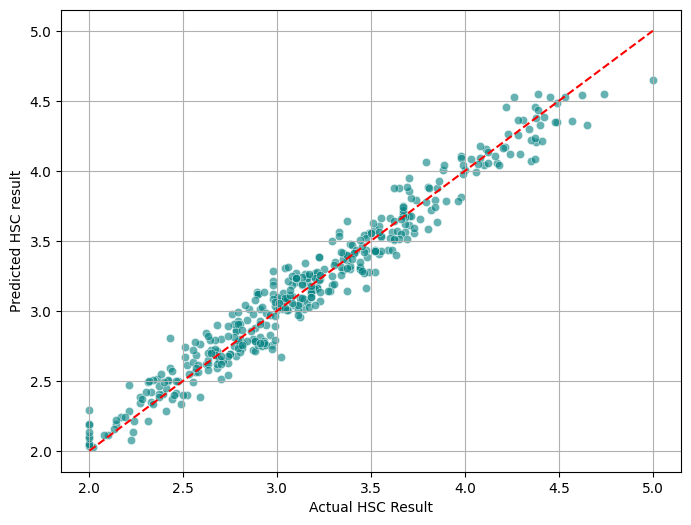

In [100]:
best_model_name = results_df.iloc[0]['Model']
best_model_obj = model_to_train[best_model_name]


#fit the best model

final_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model',best_model_obj)
])

final_pipe.fit(X_train,y_train)
y_final_pred = final_pipe.predict(X_test)


#plot Actual vs predicted

plt.figure( figsize = (8,6) )

sns.scatterplot(x=y_test, y=y_final_pred, alpha = 0.6, color='teal' )
plt.plot( [2,5] , [2,5], color = "red", linestyle = '--'  )

plt.xlabel("Actual HSC Result")
plt.ylabel("Predicted HSC result")

plt.grid(True)
plt.show()

#Cross Valiadation

In [101]:
from sklearn.model_selection import cross_val_score

In [102]:
rf_pipeline = Pipeline(
    [
        ('preprocessor',preprocessor),
        ('model',RandomForestRegressor(n_estimators=100,random_state=42))

     ]

  )

In [103]:
# cross validation

In [104]:
# 5 fold cv

cv_scores = cross_val_score( rf_pipeline,X_train,y_train,cv=5, scoring='neg_mean_squared_error' )
cv_rmse = np.sqrt(-cv_scores)

print(cv_rmse)

[0.13825617 0.14202924 0.15369812 0.14773708 0.12940278]


In [105]:
print(cv_rmse.mean())

0.14222467953735998


In [106]:
print(cv_rmse.std())

0.00827302663832195


# Stacking Ensemble

In [107]:
stacking_pipeline = Pipeline(
    [
        ('preprocessor',preprocessor),
        ('model',stacking_reg)

     ]

  )

In [108]:
cv_scores = cross_val_score(
    stacking_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs = -1 #use all processor core , to speed it up
    )

stacking_rmse = np.sqrt(-cv_scores)

print(stacking_rmse)

[0.12742194 0.1342731  0.13336693 0.13391606 0.11927744]


# Grid search cv

In [109]:
rf_pipeline = Pipeline(
    [
        ('preprocessor',preprocessor),
        ('model',RandomForestRegressor(n_estimators=100,random_state=42))

     ]

  )

In [110]:
#define the grid

param_grid = {
    'model__n_estimators' : [100,200] ,
    'model__max_depth': [None,10,20],
    'model__min_samples_split' : [2,5]
}

In [111]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator = rf_pipeline,
    param_grid = param_grid,
    cv = 5 ,
    scoring = 'neg_root_mean_squared_error',
    n_jobs =-1,
    verbose = 2

)

In [112]:
grid_search.fit(X_train,y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['st_age', 'm_edu', 'f_edu', 'tuition_fee', 'time_with_friends',
       'ssc_result'],
      dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_...
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         Index(['st_gender', 'st_address', 'st_fam_size', 'pstatus', 'm_job', 'f_job',
       'st_relationship', 'smoker'],
      dtype='object'))])),
                                       ('model',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='neg_root_mean_squared_error', verbose=2)

In [113]:
print(-grid_search.best_score_)

0.14145800733122194


In [114]:
print(grid_search.best_params_)

{'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 200}


# Randomized Search cv

In [115]:
from scipy.stats import randint

my_dist = randint(1,10)

print(my_dist.rvs())
print(my_dist.rvs())
print(my_dist.rvs(size=5))

7
5
[3 4 3 4 8]


In [116]:
rf_pipeline = Pipeline(
    [
        ('preprocessor',preprocessor),
        ('model',RandomForestRegressor(n_estimators=100,random_state=42))

     ]

  )

In [117]:
param_dist = {
    'model__n_estimators' : randint(100,500) ,
    'model__max_depth': [None,10,20],
    'model__min_samples_split' : randint(1,10)
}

In [118]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator = rf_pipeline,
    param_distributions = param_dist,
    n_iter=1,
    cv = 5 ,
    scoring = 'neg_root_mean_squared_error',
    n_jobs =-1,
    verbose = 2,
    random_state = 42
)

In [119]:
random_search.fit(X_train,y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               Index(['st_age', 'm_edu', 'f_edu', 'tuition_fee', 'time_with_friends',
       'ssc_result'],
      dtype='object')),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy=...
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=1, n_jobs=-1,
                   param_distributions={'model__max_depth': [None, 10, 20],
                                        'model__min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7eb48b97d760>,
                                        'model__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7eb4811079e0>},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=2)

In [120]:
print( -random_search.best_score_ )

0.14084993368592363


In [121]:
print( random_search.best_params_ )

{'model__max_depth': 20, 'model__min_samples_split': 4, 'model__n_estimators': 448}


# Save Model

In [122]:
import pickle
from sklearn.linear_model import LinearRegression

X_train_lr = [ [1],[2],[3],[4],[5] ]  #study
y_train_lr = [10,20,30,40,50] #marks

model = LinearRegression()

model.fit(X_train_lr,y_train_lr)

LinearRegression()

In [123]:
model.predict( [ [6] ] )[0]

np.float64(59.99999999999999)

In [124]:
# save file
filename = "model.pkl"

with open( filename, "wb" ) as file:
  pickle.dump( model, file )

In [125]:
#load

with open( "/content/model.pkl", "rb" ) as file:
  loaded_model = pickle.load(file)

In [126]:
loaded_model.predict( [[7 ]] )[0]

np.float64(70.0)

#random forest

In [127]:
# save pickle file
filename = "random_forest_model.pkl"

with open( filename, "wb" ) as file:
  pickle.dump( random_search, file )

In [128]:
with open( "/content/random_forest_model.pkl", "rb" ) as file:
  rf_loaded_model = pickle.load(file)

In [129]:
rf_loaded_model.predict(X_test)

array([3.25358486, 3.65175455, 3.6839633 , 3.93819993, 4.10968009,
       3.27100146, 4.09964785, 2.50801055, 2.10108091, 3.27545334,
       3.57527603, 2.93104246, 3.19883064, 4.50315353, 3.01832587,
       2.63595385, 3.61609093, 3.35818275, 2.87920878, 2.86785921,
       2.76008559, 3.18987175, 2.88704874, 3.23378842, 2.05378079,
       2.64788877, 3.2270904 , 4.03147561, 3.11436372, 4.09647478,
       2.46314233, 3.84002564, 4.50155471, 2.57208642, 3.19078939,
       3.2159185 , 2.75204488, 3.57201338, 2.45261863, 2.60539475,
       2.99196933, 2.96515428, 3.65012611, 2.77703321, 2.32451346,
       3.00689   , 2.61717685, 2.70184354, 4.10520044, 3.21635044,
       2.99176609, 3.40897047, 4.23238369, 3.54569106, 2.98419703,
       3.23721836, 3.26701938, 2.79513402, 3.71203732, 2.70813892,
       3.03779936, 2.65597916, 2.50947728, 4.43437225, 2.58081199,
       3.2271024 , 3.86644784, 2.72599214, 3.06783388, 3.23638222,
       3.01162682, 2.63232789, 2.70175537, 3.43699125, 3.03988

# MLFLOW

In [130]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 80.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.5/780.5 kB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 12.4 MB/s eta 0:00:00


# Let's Discover MLflow


In [131]:
import mlflow

In [132]:
mlflow.set_tracking_uri("file:///content/mlruns") # folder creation
mlflow.set_experiment("test_run")

with mlflow.start_run( run_name = "Dummy_test" ):

  #metric
  mlflow.log_metric( "Accuracy", 0.95 )
  mlflow.log_metric( "Loss", 0.05 )

  #parameter

  mlflow.log_param("model_type","fake_model_v1")
  mlflow.log_param("Learning Rate",0.001)



2026/01/18 17:13:31 INFO mlflow.tracking.fluent: Experiment with name 'test_run' does not exist. Creating a new experiment.


# RF using MLFLOW

In [133]:
import mlflow
import mlflow.sklearn
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

mlflow.set_experiment("Student performance using rf")

my_params = {
    'n_estimators' :100,
    'max_depth' :10,
    'random_state' : 42
}

simple_rf_pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('model',RandomForestRegressor(**my_params))
])


#start mlflow

with mlflow.start_run( run_name = "Single_rf"):

  mlflow.log_params(my_params)

  mlflow.log_param("model_type","RandomForestRegressor")

  #train
  simple_rf_pipeline.fit(X_train,y_train)

  y_train_pred = simple_rf_pipeline.predict(X_train)
  train_rmse = np.sqrt(mean_squared_error(y_train,y_train_pred))

  #log train details

  mlflow.log_metric("train rmse",train_rmse)

  #test

  y_test_pred = simple_rf_pipeline.predict(X_test)
  test_rmse = np.sqrt(mean_squared_error(y_test,y_test_pred))

  mlflow.log_metric("test_rmse",test_rmse)







2026/01/18 17:27:05 INFO mlflow.tracking.fluent: Experiment with name 'Student performance using rf' does not exist. Creating a new experiment.


In [134]:
test_rmse

np.float64(0.13592219413742918)